In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xg

In [2]:
df = pd.read_csv(r"C:\Users\aaryan\Downloads\archive\GlobalWeatherRepository.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129808 entries, 0 to 129807
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       129808 non-null  object 
 1   location_name                 129808 non-null  object 
 2   latitude                      129808 non-null  float64
 3   longitude                     129808 non-null  float64
 4   timezone                      129808 non-null  object 
 5   last_updated_epoch            129808 non-null  int64  
 6   last_updated                  129808 non-null  object 
 7   temperature_celsius           129808 non-null  float64
 8   temperature_fahrenheit        129808 non-null  float64
 9   condition_text                129808 non-null  object 
 10  wind_mph                      129808 non-null  float64
 11  wind_kph                      129808 non-null  float64
 12  wind_degree                   129808 non-nul

In [3]:
#data cleaning and preprocessing

In [4]:
#null and duplicate values
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [5]:
df.head(2)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55


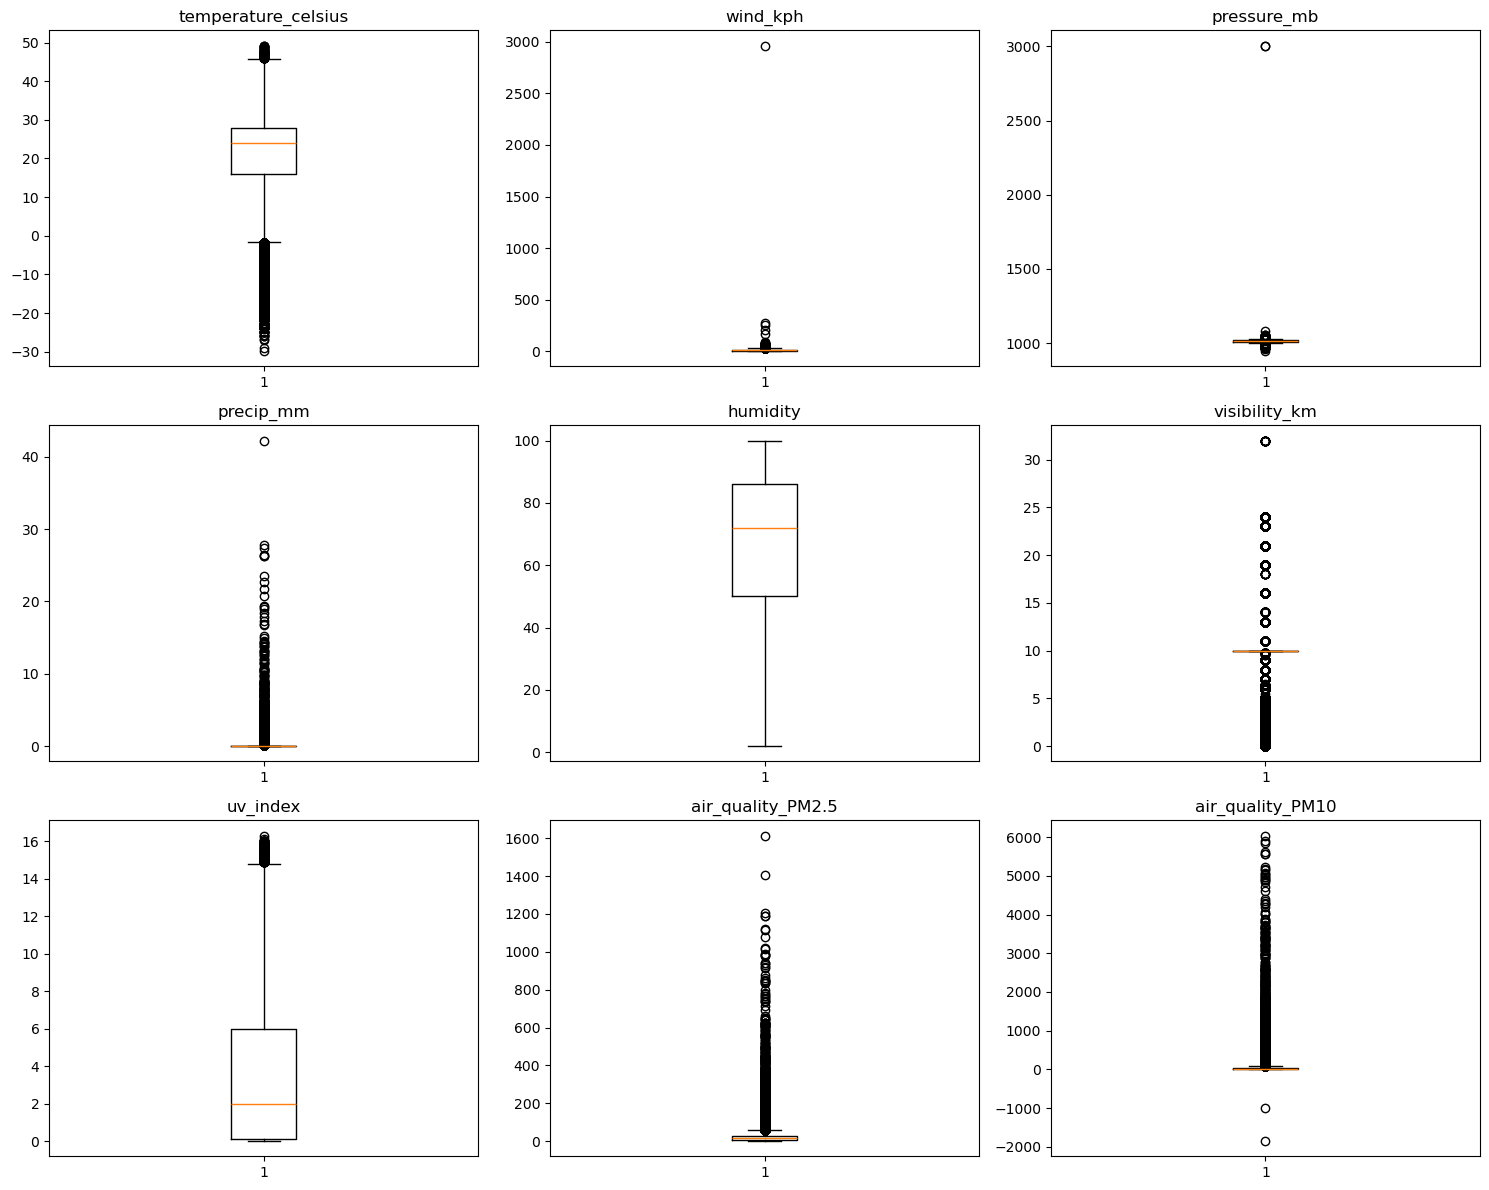

In [6]:
#checking for outliers
cols_to_plot = ["temperature_celsius","wind_kph","pressure_mb","precip_mm","humidity","visibility_km","uv_index", "air_quality_PM2.5", "air_quality_PM10"]
fig,axes = plt.subplots(3,3,figsize=(15,12))
axes = axes.flatten()

for i , col in enumerate(cols_to_plot):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [7]:
#fixing outliers using IQR
cols_to_clean = ["temperature_celsius","wind_kph","pressure_mb","precip_mm","visibility_km","uv_index", "air_quality_PM2.5", "air_quality_PM10"]
for col in cols_to_clean:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    #capping the outliers
    df[col] = np.where(df[col]<lower_bound , lower_bound , df[col])
    df[col] = np.where(df[col]>upper_bound , upper_bound , df[col])
print("outliers capped")

outliers capped


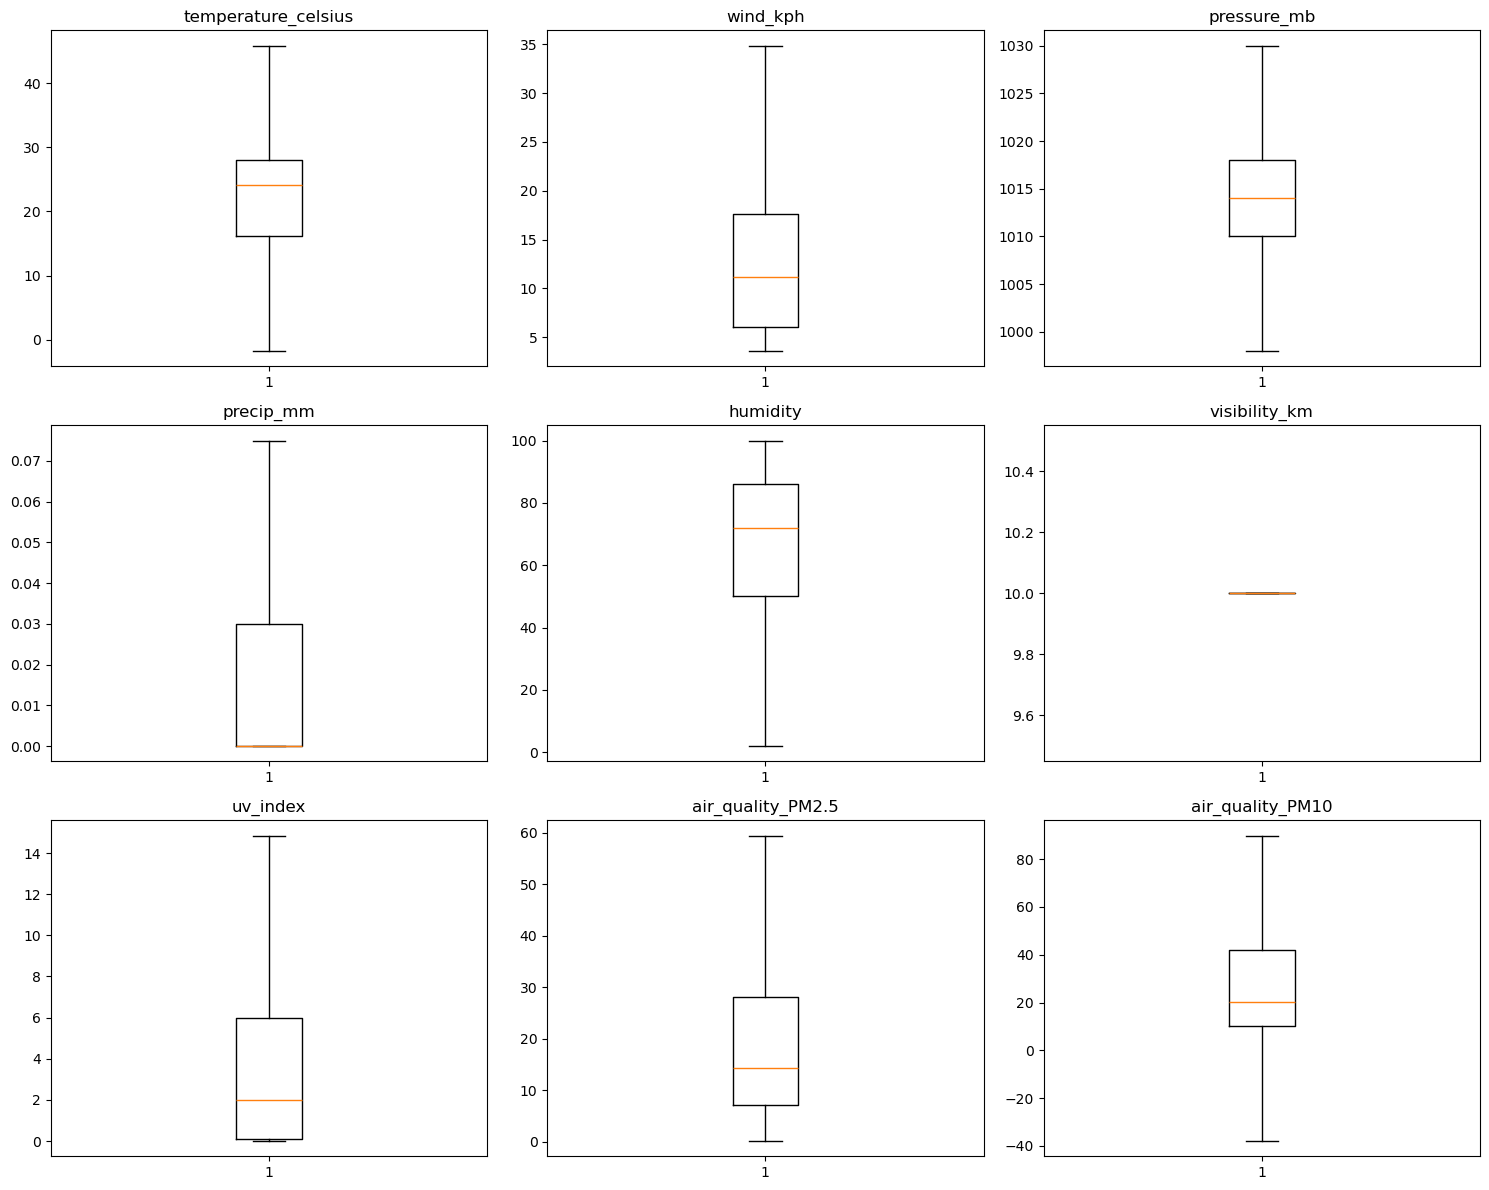

In [8]:
#check 
cols_to_plot = ["temperature_celsius","wind_kph","pressure_mb","precip_mm","humidity","visibility_km","uv_index", "air_quality_PM2.5", "air_quality_PM10"]
fig,axes = plt.subplots(3,3,figsize=(15,12))
axes = axes.flatten()

for i , col in enumerate(cols_to_plot):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [9]:
#normalization
cols_to_normalize = ["temperature_celsius","wind_kph","pressure_mb","precip_mm","humidity","visibility_km","uv_index", "air_quality_PM2.5", "air_quality_PM10"]
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])
df[cols_to_normalize].head()

,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,visibility_km,uv_index,air_quality_PM2.5,air_quality_PM10
0,0.595588,0.3104,0.43750,0.0,0.224490,0.0,0.471380,0.138923,0.504890
1,0.435924,0.2432,0.43750,1.0,0.938776,0.0,0.336700,0.015728,0.312402
2,0.519958,0.3680,0.40625,0.0,0.275510,0.0,0.336700,0.172675,0.440728
3,0.169118,0.2656,0.28125,1.0,0.602041,0.0,0.134680,0.008978,0.303795
4,0.582983,0.3008,0.40625,0.0,0.887755,0.0,0.538721,1.000000,1.000000


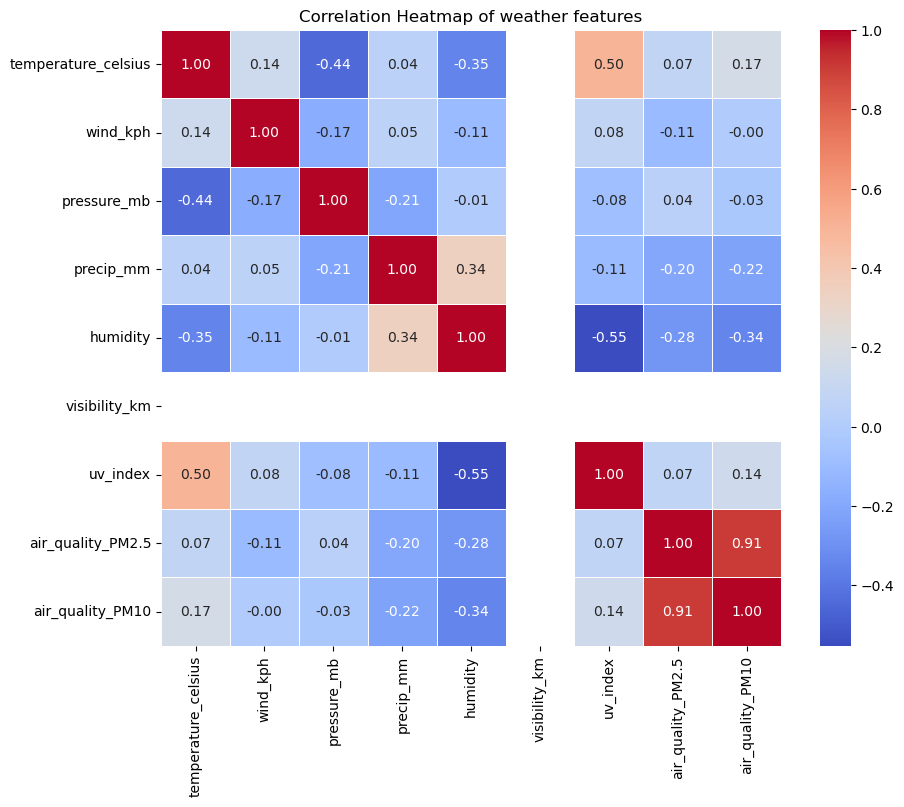

In [10]:
#EDA
#1) Trends, correlations, aur patterns
numerical_cols = [
    "temperature_celsius", "wind_kph", "pressure_mb", 
    "precip_mm", "humidity", "visibility_km", 
    "uv_index", "air_quality_PM2.5", "air_quality_PM10"
]
#correlation matrix
corr_matrix = df[numerical_cols].corr()
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap of weather features")
plt.show()

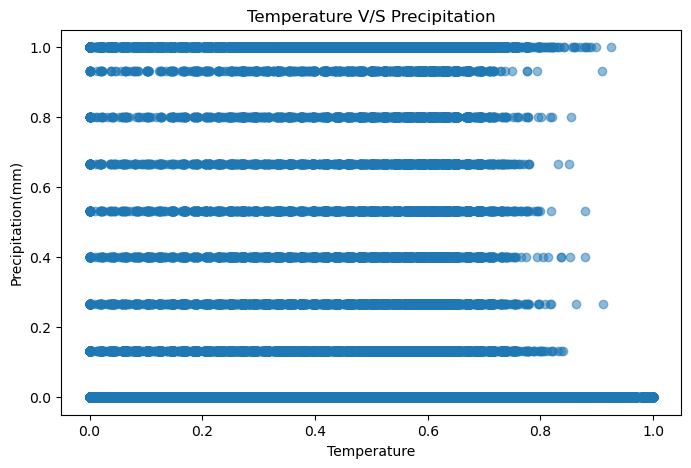

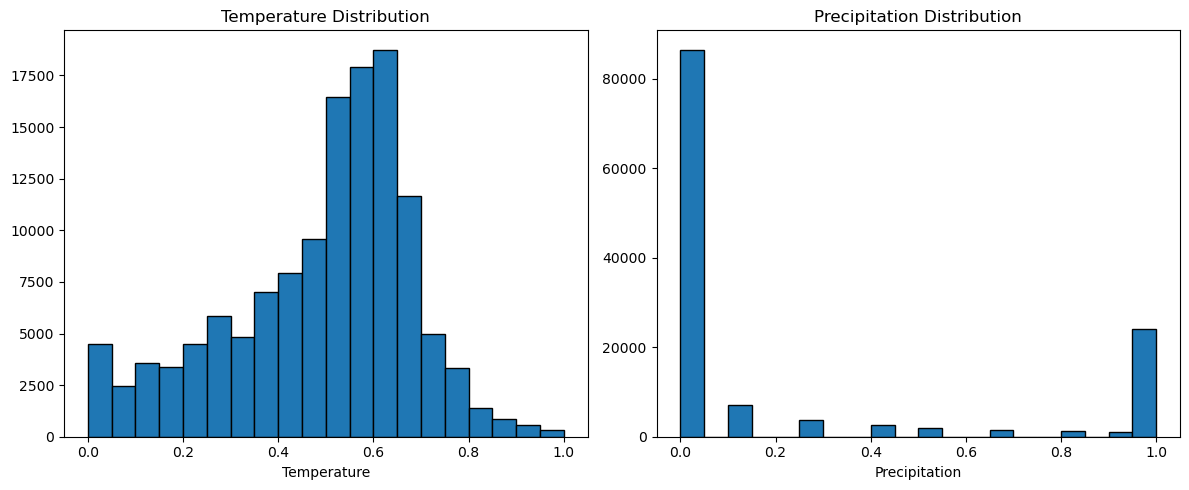

In [11]:
#generating histogram for temperature and precipitation
plt.figure(figsize=(8,5))
plt.scatter(df["temperature_celsius"],df["precip_mm"],alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Precipitation(mm)")
plt.title("Temperature V/S Precipitation")
plt.show()

#Histogram for temperature and precipitation
fig , axes = plt.subplots(1,2 , figsize=(12,5))
axes[0].hist(df["temperature_celsius"], bins=20, edgecolor='black')
axes[0].set_title("Temperature Distribution")
axes[0].set_xlabel("Temperature")

axes[1].hist(df["precip_mm"], bins=20, edgecolor='black')
axes[1].set_title("Precipitation Distribution")
axes[1].set_xlabel("Precipitation")

plt.tight_layout()
plt.show()

In [12]:
#model building

#converting last_updated column to real date time
df["last_updated"] = pd.to_datetime(df["last_updated"])
df = df.sort_values(by="last_updated")

#seperating time features for model
df["month"] = df["last_updated"].dt.month
df["day"] = df["last_updated"].dt.day
df["hour"] = df["last_updated"].dt.hour

df[["last_updated","month","day","hour"]].head()

,last_updated,month,day,hour
186,2024-05-16 01:45:00,5,16,1
74,2024-05-16 02:45:00,5,16,2
52,2024-05-16 02:45:00,5,16,2
68,2024-05-16 02:45:00,5,16,2
17,2024-05-16 02:45:00,5,16,2


In [13]:
y = df["temperature_celsius"]
features = ["wind_kph", "pressure_mb", "precip_mm", "humidity", "visibility_km", "uv_index", "air_quality_PM2.5", "air_quality_PM10", "month", "day", "hour"]
X = df[features]

In [14]:
#splitting and training 
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = RandomForestRegressor() 
model.fit(X_train,y_train)

RandomForestRegressor()

In [15]:
#testing
y_pred = model.predict(X_test)
#r2 score
rf_r2_score = r2_score(y_test,y_pred)
print(f"R2 Score : {rf_r2_score}")
#mse and rmse
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

R2 Score : 0.8745947792234835
Mean Squared Error (MSE): 0.004794595985018169
Root Mean Squared Error (RMSE): 0.06924302120082694


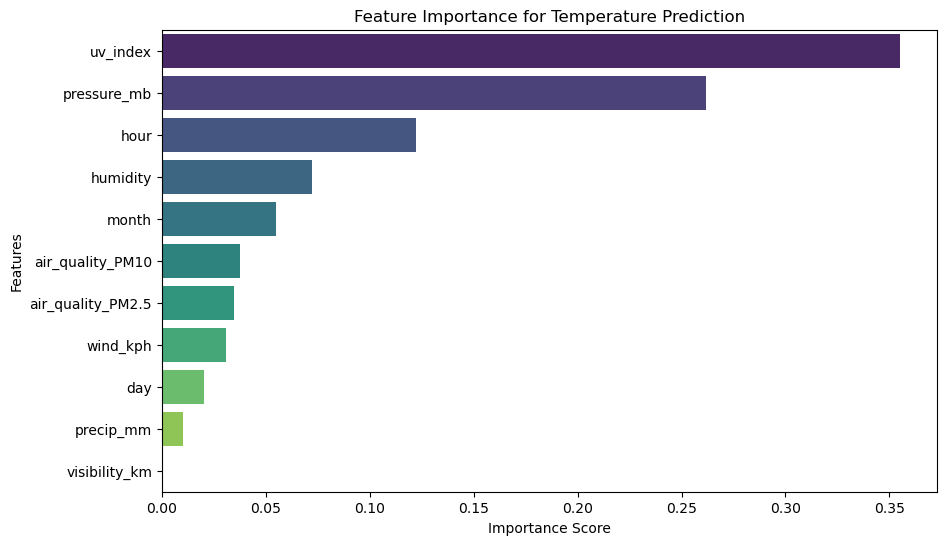

In [16]:
#feature importance
importances = model.feature_importances_
feature_names = X.columns
#dataframe for sorting 
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
#bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis", hue="Feature", legend=False)
plt.title("Feature Importance for Temperature Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [17]:
# !pip install xgboost

In [18]:
#Using xbboost model
xgb_model = xg.XGBRegressor(n_estimators=500,learning_rate=0.05,max_depth=8,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
y_pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost R2 Score: {r2_xgb}")

XGBoost R2 Score: 0.8798661930893078


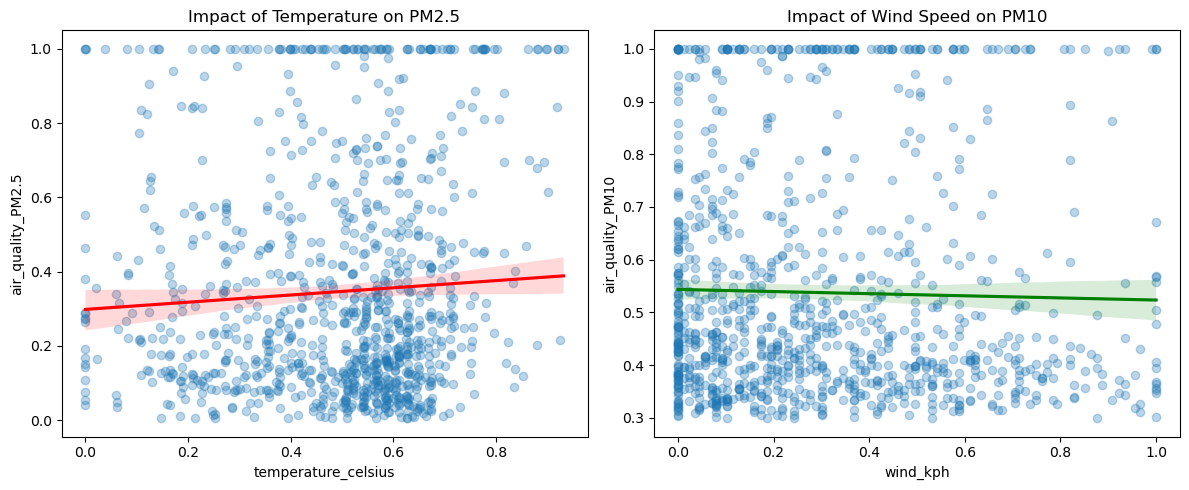

In [20]:
#Environmental Impact Analysis
plt.figure(figsize=(12, 5))
#Temperature v/s Air Quality(PM2.5)
plt.subplot(1, 2, 1)
sns.regplot(x="temperature_celsius", y="air_quality_PM2.5", data=df.sample(1000), scatter_kws={"alpha":0.3}, line_kws={"color":"red"})
plt.title("Impact of Temperature on PM2.5")

#Wind Speed vs Air Quality(PM10)
plt.subplot(1, 2, 2)
sns.regplot(x="wind_kph", y="air_quality_PM10", data=df.sample(1000), scatter_kws={"alpha":0.3}, line_kws={"color":"green"})
plt.title("Impact of Wind Speed on PM10")

plt.tight_layout()
plt.show()

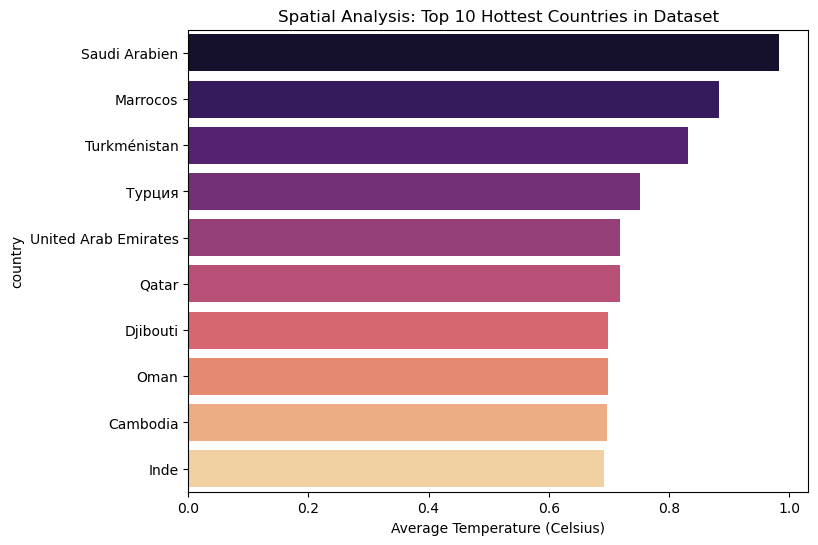

In [21]:
#Spatial Analysis: Top 10 Countries by Temperature
plt.figure(figsize=(8, 6))
top_countries = df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma", hue=top_countries.index, legend=False)
plt.title("Spatial Analysis: Top 10 Hottest Countries in Dataset")
plt.xlabel("Average Temperature (Celsius)")
plt.show()

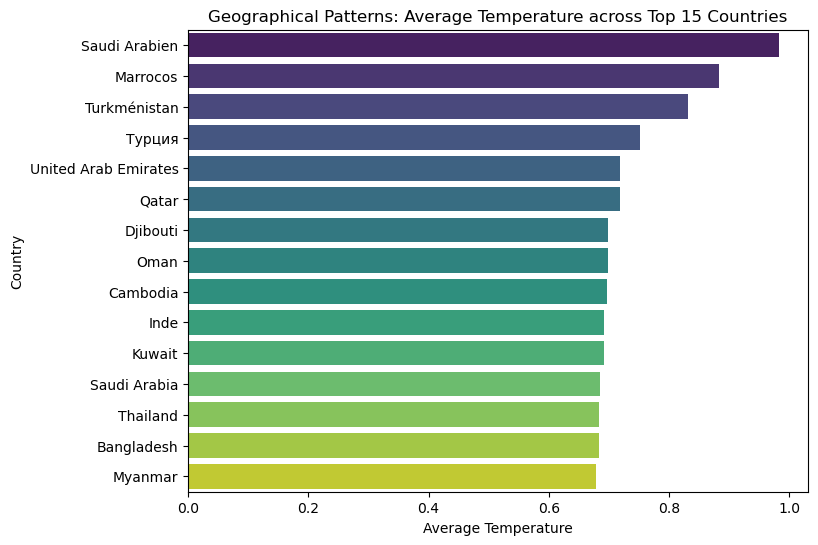

In [22]:
# 1. Geographical Analysis: Average Temperature by Country (Top 15)
plt.figure(figsize=(8, 6))
country_avg = df.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=country_avg.values, y=country_avg.index, palette="viridis", hue=country_avg.index, legend=False)
plt.title("Geographical Patterns: Average Temperature across Top 15 Countries")
plt.xlabel("Average Temperature")
plt.ylabel("Country")
plt.show()

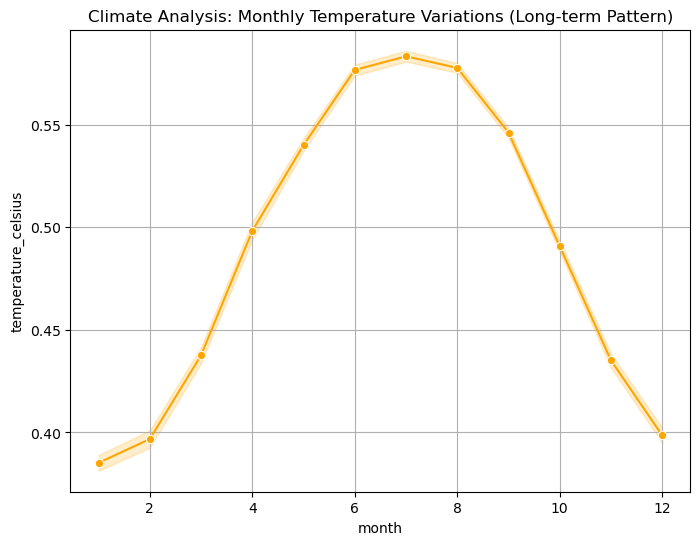

In [23]:
# Climate Analysis: Temperature trend over months
plt.figure(figsize=(8, 6))
sns.lineplot(x="month", y="temperature_celsius", data=df, marker="o", color="orange")
plt.title("Climate Analysis: Monthly Temperature Variations (Long-term Pattern)")
plt.grid(True)
plt.show()

In [24]:
#Final Ensemble Model (XGBoost + Random Forest)
y_final_ensemble = (model.predict(X_test) + xgb_model.predict(X_test)) / 2
print(f"Final Ensemble Model R2 Score: {r2_score(y_test, y_final_ensemble)}")

Final Ensemble Model R2 Score: 0.8846130775829466
